# Classificação de Câncer de Mama com KNN

## Objetivo
Aplicar o algoritmo K-Nearest Neighbors (KNN) para classificar tumores como benignos ou malignos.

## Dataset
Breast Cancer Wisconsin (sklearn)

## Etapas:
- Carregamento de dados
- Análise exploratória
- Pré-processamento
- Treinamento (KNN)
- Avaliação
- Experimentos com k

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Formato dos dados:", X.shape)
X.head()

Formato dos dados: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print("Classes:", data.target_names)
print("\nDistribuição das classes:")
print(pd.Series(y).value_counts())

Classes: ['malignant' 'benign']

Distribuição das classes:
1    357
0    212
Name: count, dtype: int64


In [ ]:
print("\nEstatísticas:")
X.describe()


Estatísticas:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


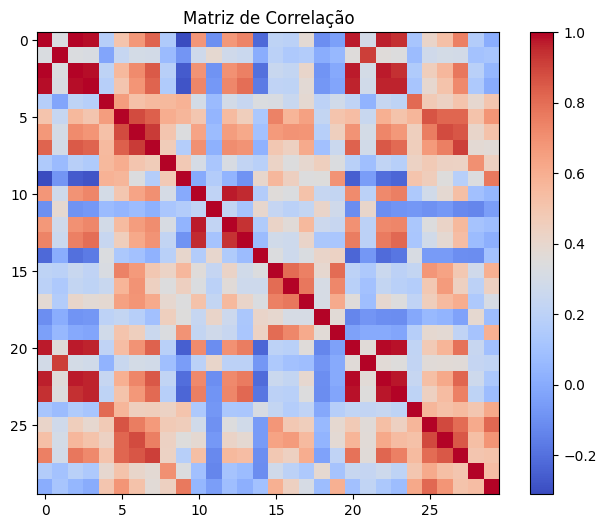

In [ ]:
# Correlação (simplificada)
corr = X.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.title("Matriz de Correlação")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (398, 30)
Teste: (171, 30)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
k = 5

model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = model.predict(X_test_scaled)

print("Acurácia:", accuracy_score(y_test, y_pred))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório:")
print(classification_report(y_test, y_pred))

Acurácia: 0.9590643274853801

Matriz de confusão:
[[ 57   7]
 [  0 107]]

Relatório:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        64
           1       0.94      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



# 📘 Interpretação da Matriz de Confusão

O comando:

```python
print(confusion_matrix(y_test, y_pred))
````

retorna uma matriz no formato:

\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}

---

## 🟦 Estrutura da Matriz

|             | Predito: 0 | Predito: 1 |
| ----------- | ---------- | ---------- |
| **Real: 0** | TN         | FP         |
| **Real: 1** | FN         | TP         |

---

## 🟦 Significado de cada termo

### ✔ TN (True Negative)

* Modelo previu **negativo corretamente**
* Ex: disse que o tumor é **benigno** e realmente é benigno

---

### ✔ FP (False Positive)

* Modelo previu **positivo incorretamente**
* Ex: disse que é **maligno**, mas é benigno
* Também chamado de **falso alarme**

---

### ✔ FN (False Negative) ⚠️

* Modelo previu **negativo incorretamente**
* Ex: disse que é **benigno**, mas é maligno
* **Erro mais grave no contexto médico**

---

### ✔ TP (True Positive)

* Modelo previu **positivo corretamente**
* Ex: disse que é **maligno** e realmente é maligno

---

## 🧠 Exemplo prático

Saída:

```python
[[60  3]
 [ 5 103]]
```

Interpretação:

* **60** → benignos corretamente classificados (TN)
* **3** → benignos classificados como malignos (FP)
* **5** → malignos classificados como benignos (FN) ⚠️
* **103** → malignos corretamente classificados (TP)

---

## 🟦 Interpretação no problema de câncer

👉 O erro mais crítico é:

### ⚠️ False Negative (FN)

* Paciente tem câncer
* Modelo diz que não tem

➡️ Pode impedir diagnóstico e tratamento

---

## 🟦 Métricas derivadas

### ✔ Acurácia

$$
\frac{TP + TN}{Total}
$$

---

### ✔ Recall (Sensibilidade)

$$
\frac{TP}{TP + FN}
$$

👉 Mede quantos casos positivos foram detectados

---

### ✔ Precisão

$$
\frac{TP}{TP + FP}
$$

👉 Mede quantos positivos previstos estão corretos

---

## 🧠 Insight importante

> Nem todo erro tem o mesmo peso — a matriz de confusão revela isso.

---

## 🎯 Pergunta para reflexão

👉 Qual erro é mais grave nesse problema? Por quê?


---

## 📌 Resumo

* **TN** → acerto (negativo)
* **FP** → falso alarme
* **FN** → erro crítico
* **TP** → acerto (positivo)




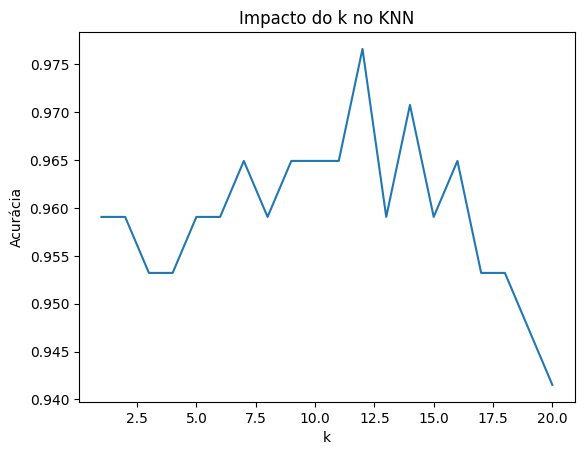

In [ ]:
ks = range(1, 21)
accuracies = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure()
plt.plot(ks, accuracies)
plt.xlabel("k")
plt.ylabel("Acurácia")
plt.title("Impacto do k no KNN")
plt.show()

In [ ]:
best_k = ks[np.argmax(accuracies)]
print("Melhor k:", best_k)
print("Melhor acurácia:", max(accuracies))

Melhor k: 12
Melhor acurácia: 0.9766081871345029


In [ ]:
novo = X.iloc[[0]]  # só para teste

novo_scaled = scaler.transform(novo)

model = KNeighborsClassifier(n_neighbors=12)
model.fit(X_train_scaled, y_train)
pred = model.predict(novo_scaled)
prob = model.predict_proba(novo_scaled)

print("Classe prevista:", data.target_names[pred[0]])
print("Probabilidades:", prob[0])

Classe prevista: malignant
Probabilidades: [1. 0.]


## Perguntas

1. Por que o KNN precisa de normalização?
2. O que acontece quando k = 1?
3. O que acontece quando k é muito grande?
4. Qual métrica seria mais importante neste problema: precisão ou recall?
5. KNN seria adequado para datasets muito grandes? Por quê?